In [48]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Load dataset (use your file path)
df = pd.read_csv("../bank-full.csv", sep=';')

# Show first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [50]:
# Dataset shape (rows, columns)
print("Shape:", df.shape)
df.info()

#df.describe()

Shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [51]:
# Check missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

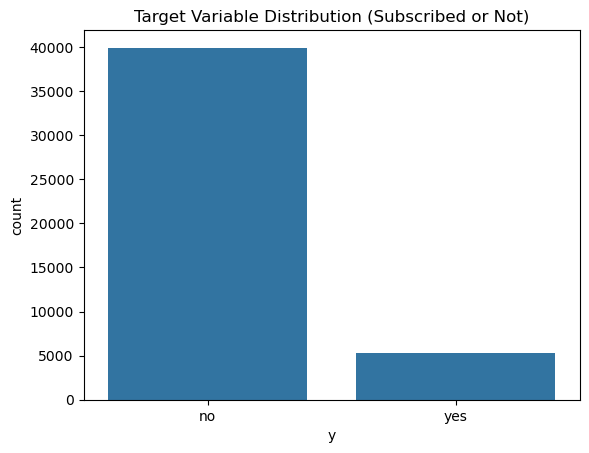

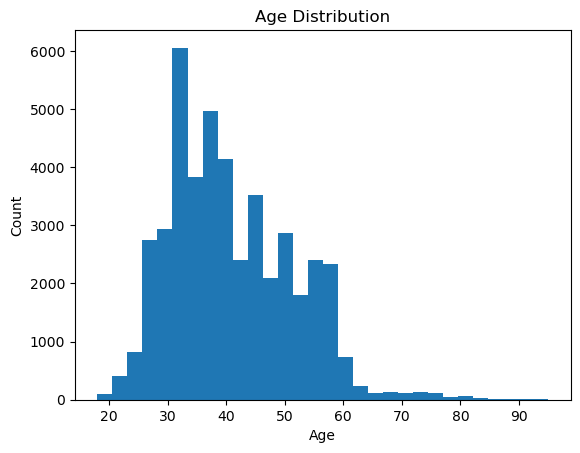

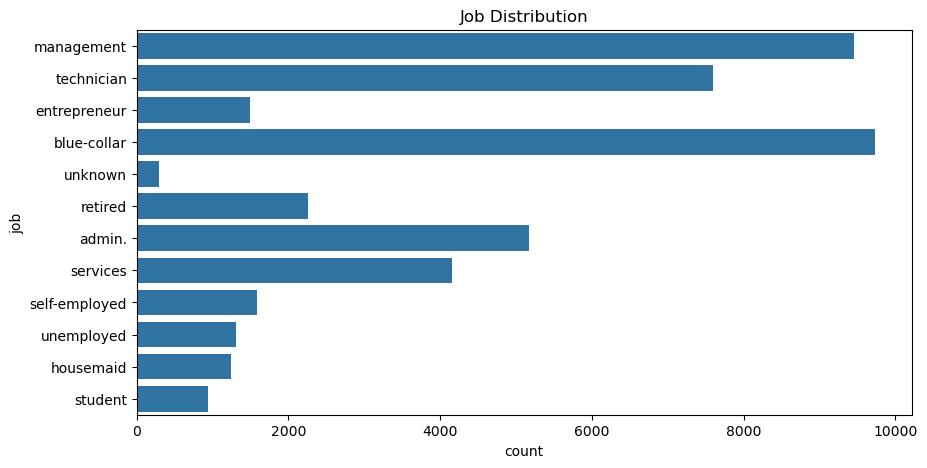

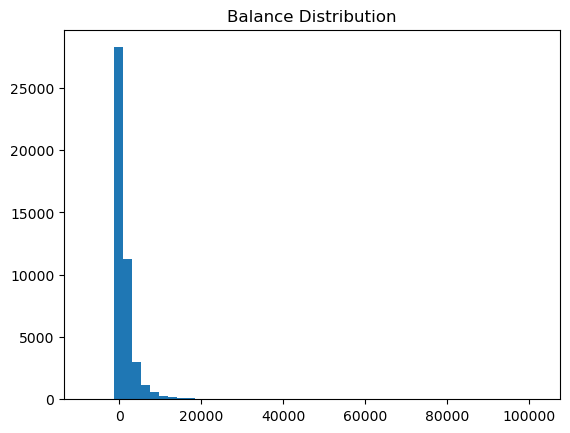

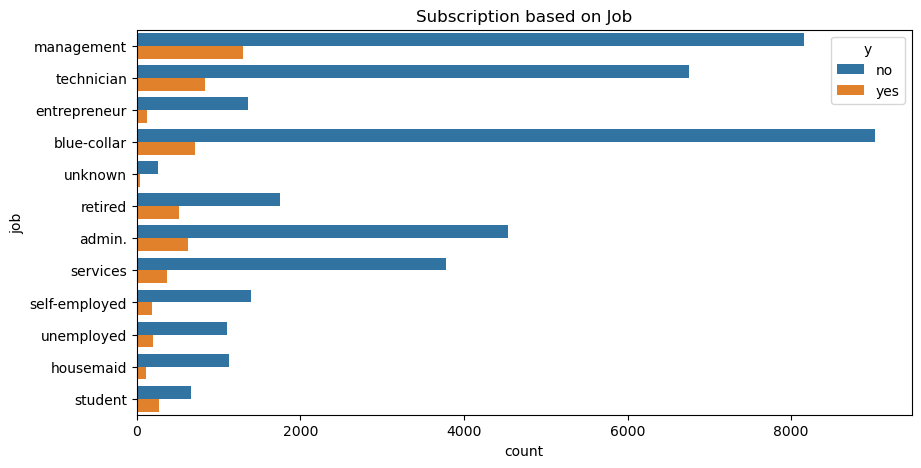

In [52]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution (Subscribed or Not)")
plt.show() #get an idea if Data is imbalanced


plt.hist(df['age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(y='job', data=df)
plt.title("Job Distribution")
plt.show()

plt.hist(df['balance'], bins=50)
plt.title("Balance Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(y='job', hue='y', data=df)
plt.title("Subscription based on Job")
plt.show()


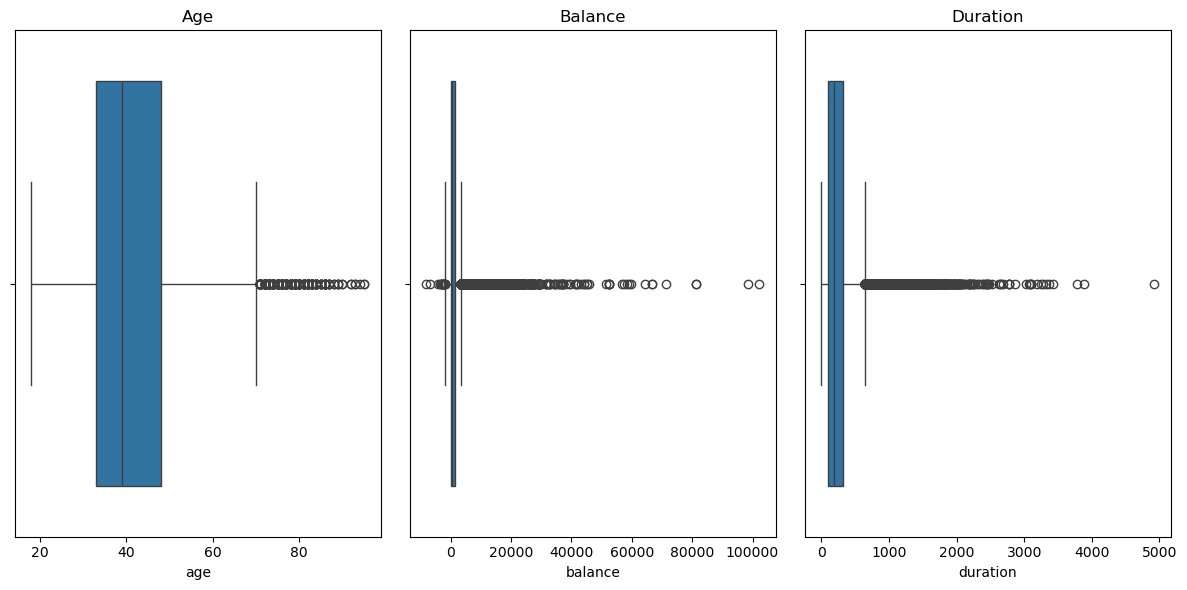

In [53]:
#Display Outliers
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
sns.boxplot(x=df['age'])
plt.title("Age")

plt.subplot(1,3,2)
sns.boxplot(x=df['balance'])
plt.title("Balance")

plt.subplot(1,3,3)
sns.boxplot(x=df['duration'])
plt.title("Duration")

plt.tight_layout()
plt.show()



In [54]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['balance'] >= lower) & (df['balance'] <= upper)]

print("After removing balance outliers:", df.shape)

After removing balance outliers: (40482, 17)


In [55]:
#Clipping duretion variable
upper_limit = df['duration'].quantile(0.95)


df['duration'] = df['duration'].clip(upper=upper_limit)


print("Max duration after clipping:", df['duration'].max())

Max duration after clipping: 743.9499999999971


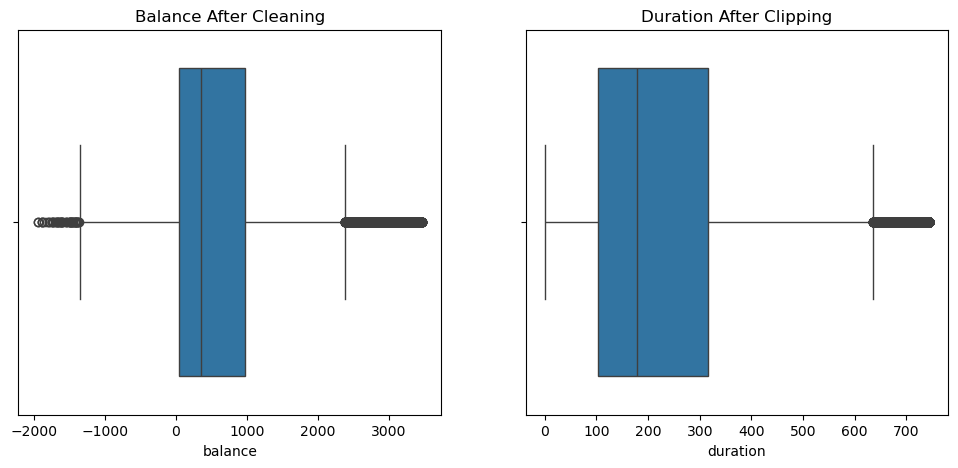

In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['balance'])
plt.title("Balance After Cleaning")

plt.subplot(1,2,2)
sns.boxplot(x=df['duration'])
plt.title("Duration After Clipping")

plt.show()

In [57]:
# Convert categorical columns to numbers
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y_yes
0,58,2143,5,261.0,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,44,29,5,151.0,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,33,2,5,76.0,1,-1,0,False,True,False,...,False,False,True,False,False,False,False,False,True,False
3,47,1506,5,92.0,1,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,33,1,5,198.0,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [58]:
 # Save preprocessed data to a new CSV file
df_encoded.to_csv('preprocessed_data.csv', index=False)

print("Preprocessing completed ✅")

Preprocessing completed ✅
